# Song Recommendation System using Audio Features
This project builds a content-based music recommendation system based on audio features such as danceability, energy, loudness and tempo.
The goal is to recommend songs that are similar in musical characteristics to a given input track.

## Project Goals
- Explore the distribution of audio features
- Analyse relationships between musical attributes
- Build a content-based recommender system
- Recommend similar songs based on audio features

## Dataset
The dataset contains audio features for a large number of songs.  
Each track includes musical attributes extracted from audio analysis.

Key variables include:

- danceability: how suitable a track is for dancing
- energy: intensity and activity of the track
- loudness: overall loudness in decibels
- valence: musical positiveness
- tempo: beats per minute

### Load Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.patches import Patch

### Load Dataset

In [2]:
df = pd.read_csv("../data/sample.csv")

print(df.shape)
print(df.columns)
df.head()

(99888, 17)
Index(['name', 'artists', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'year', 'song_label', 'PC1', 'PC2', 'cluster', 'cluster_name'],
      dtype='object')


,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year,song_label,PC1,PC2,cluster,cluster_name
0,All Along The Watchtower - Live - 1991,['Indigo Girls'],0.331,0.466,-14.287,0.0379,0.709000,0.000000,0.9390,0.430,90.648,1991,All Along The Watchtower - Live - 1991 - ['Ind...,-0.175115,-0.028857,7,Live Performances
1,90210 (feat. Kacy Hill),"['Travis Scott', 'Kacy Hill']",0.402,0.526,-6.741,0.0904,0.113000,0.000008,0.1050,0.312,81.404,2015,"90210 (feat. Kacy Hill) - ['Travis Scott', 'Ka...",0.205547,-0.168948,2,Dance Pop
2,Smokin' Sticky Sticky,['Unk'],0.623,0.736,-3.657,0.4020,0.002100,0.000000,0.0691,0.422,87.988,2006,Smokin' Sticky Sticky - ['Unk'],0.462088,0.049659,2,Dance Pop
3,Holding Back the Years,['Norm Douglas'],0.585,0.639,-9.641,0.0333,0.316000,0.775000,0.0993,0.880,170.082,2008,Holding Back the Years - ['Norm Douglas'],0.324461,-0.024624,3,Instrumental Energy
4,Windmills,['Dan Friel'],0.193,0.856,-2.970,0.1090,0.000049,0.838000,0.2850,0.594,113.345,2013,Windmills - ['Dan Friel'],0.314121,-0.686464,5,Dark Electronic Instrumental


In [3]:
df.info()
print(df.isna().sum())
print("Duplikate gesamt:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99888 entries, 0 to 99887
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              99888 non-null  object 
 1   artists           99888 non-null  object 
 2   danceability      99888 non-null  float64
 3   energy            99888 non-null  float64
 4   loudness          99888 non-null  float64
 5   speechiness       99888 non-null  float64
 6   acousticness      99888 non-null  float64
 7   instrumentalness  99888 non-null  float64
 8   liveness          99888 non-null  float64
 9   valence           99888 non-null  float64
 10  tempo             99888 non-null  float64
 11  year              99888 non-null  int64  
 12  song_label        99888 non-null  object 
 13  PC1               99888 non-null  float64
 14  PC2               99888 non-null  float64
 15  cluster           99888 non-null  int64  
 16  cluster_name      99888 non-null  object

## Data Preprocessing

To prepare the dataset for the recommendation model, relevant audio features are selected

In [4]:
selected_columns = [
    "name",
    "artists",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "year"
]

df_model = df[selected_columns].copy()
df_model["song_label"] = df_model["name"].astype(str).str.strip() + " - " + df_model["artists"].astype(str).str.strip()
df_model.head()

,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year,song_label
0,All Along The Watchtower - Live - 1991,['Indigo Girls'],0.331,0.466,-14.287,0.0379,0.709000,0.000000,0.9390,0.430,90.648,1991,All Along The Watchtower - Live - 1991 - ['Ind...
1,90210 (feat. Kacy Hill),"['Travis Scott', 'Kacy Hill']",0.402,0.526,-6.741,0.0904,0.113000,0.000008,0.1050,0.312,81.404,2015,"90210 (feat. Kacy Hill) - ['Travis Scott', 'Ka..."
2,Smokin' Sticky Sticky,['Unk'],0.623,0.736,-3.657,0.4020,0.002100,0.000000,0.0691,0.422,87.988,2006,Smokin' Sticky Sticky - ['Unk']
3,Holding Back the Years,['Norm Douglas'],0.585,0.639,-9.641,0.0333,0.316000,0.775000,0.0993,0.880,170.082,2008,Holding Back the Years - ['Norm Douglas']
4,Windmills,['Dan Friel'],0.193,0.856,-2.970,0.1090,0.000049,0.838000,0.2850,0.594,113.345,2013,Windmills - ['Dan Friel']


## Feature Selection

The recommendation system is based on numerical audio features that describe musical characteristics.

The following features are used:

- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- year

In [5]:
feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "year"
]

X = df_model[feature_cols].copy().astype("float32")
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
0,0.331,0.466,-14.287,0.0379,0.709000,0.000000,0.9390,0.430,90.648003,1991.0
1,0.402,0.526,-6.741,0.0904,0.113000,0.000008,0.1050,0.312,81.403999,2015.0
2,0.623,0.736,-3.657,0.4020,0.002100,0.000000,0.0691,0.422,87.987999,2006.0
3,0.585,0.639,-9.641,0.0333,0.316000,0.775000,0.0993,0.880,170.082001,2008.0
4,0.193,0.856,-2.970,0.1090,0.000049,0.838000,0.2850,0.594,113.345001,2013.0


# Explorative Data Analysis

In [6]:
print(df_model.shape)
df_model.head()

(99888, 13)


,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year,song_label
0,All Along The Watchtower - Live - 1991,['Indigo Girls'],0.331,0.466,-14.287,0.0379,0.709000,0.000000,0.9390,0.430,90.648,1991,All Along The Watchtower - Live - 1991 - ['Ind...
1,90210 (feat. Kacy Hill),"['Travis Scott', 'Kacy Hill']",0.402,0.526,-6.741,0.0904,0.113000,0.000008,0.1050,0.312,81.404,2015,"90210 (feat. Kacy Hill) - ['Travis Scott', 'Ka..."
2,Smokin' Sticky Sticky,['Unk'],0.623,0.736,-3.657,0.4020,0.002100,0.000000,0.0691,0.422,87.988,2006,Smokin' Sticky Sticky - ['Unk']
3,Holding Back the Years,['Norm Douglas'],0.585,0.639,-9.641,0.0333,0.316000,0.775000,0.0993,0.880,170.082,2008,Holding Back the Years - ['Norm Douglas']
4,Windmills,['Dan Friel'],0.193,0.856,-2.970,0.1090,0.000049,0.838000,0.2850,0.594,113.345,2013,Windmills - ['Dan Friel']


In [7]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99888 entries, 0 to 99887
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              99888 non-null  object 
 1   artists           99888 non-null  object 
 2   danceability      99888 non-null  float64
 3   energy            99888 non-null  float64
 4   loudness          99888 non-null  float64
 5   speechiness       99888 non-null  float64
 6   acousticness      99888 non-null  float64
 7   instrumentalness  99888 non-null  float64
 8   liveness          99888 non-null  float64
 9   valence           99888 non-null  float64
 10  tempo             99888 non-null  float64
 11  year              99888 non-null  int64  
 12  song_label        99888 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 9.9+ MB


In [8]:
df_model.describe().round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
count,99888.00,99888.00,99888.00,99888.00,99888.00,99888.00,99888.00,99888.00,99888.00,99888.00
mean,0.49,0.51,-11.82,0.08,0.45,0.28,0.20,0.43,117.70,2007.34
std,0.19,0.29,6.98,0.12,0.39,0.38,0.18,0.27,30.88,10.62
min,0.00,0.00,-60.00,0.00,0.00,0.00,0.00,0.00,0.00,1900.00
25%,0.36,0.25,-15.29,0.04,0.04,0.00,0.10,0.19,94.08,2002.00
50%,0.50,0.52,-9.81,0.04,0.39,0.01,0.12,0.40,116.92,2009.00
75%,0.63,0.76,-6.72,0.07,0.86,0.71,0.24,0.64,137.18,2015.00
max,0.99,1.00,6.80,0.97,1.00,1.00,1.00,1.00,248.00,2020.00


### Feature Distributions

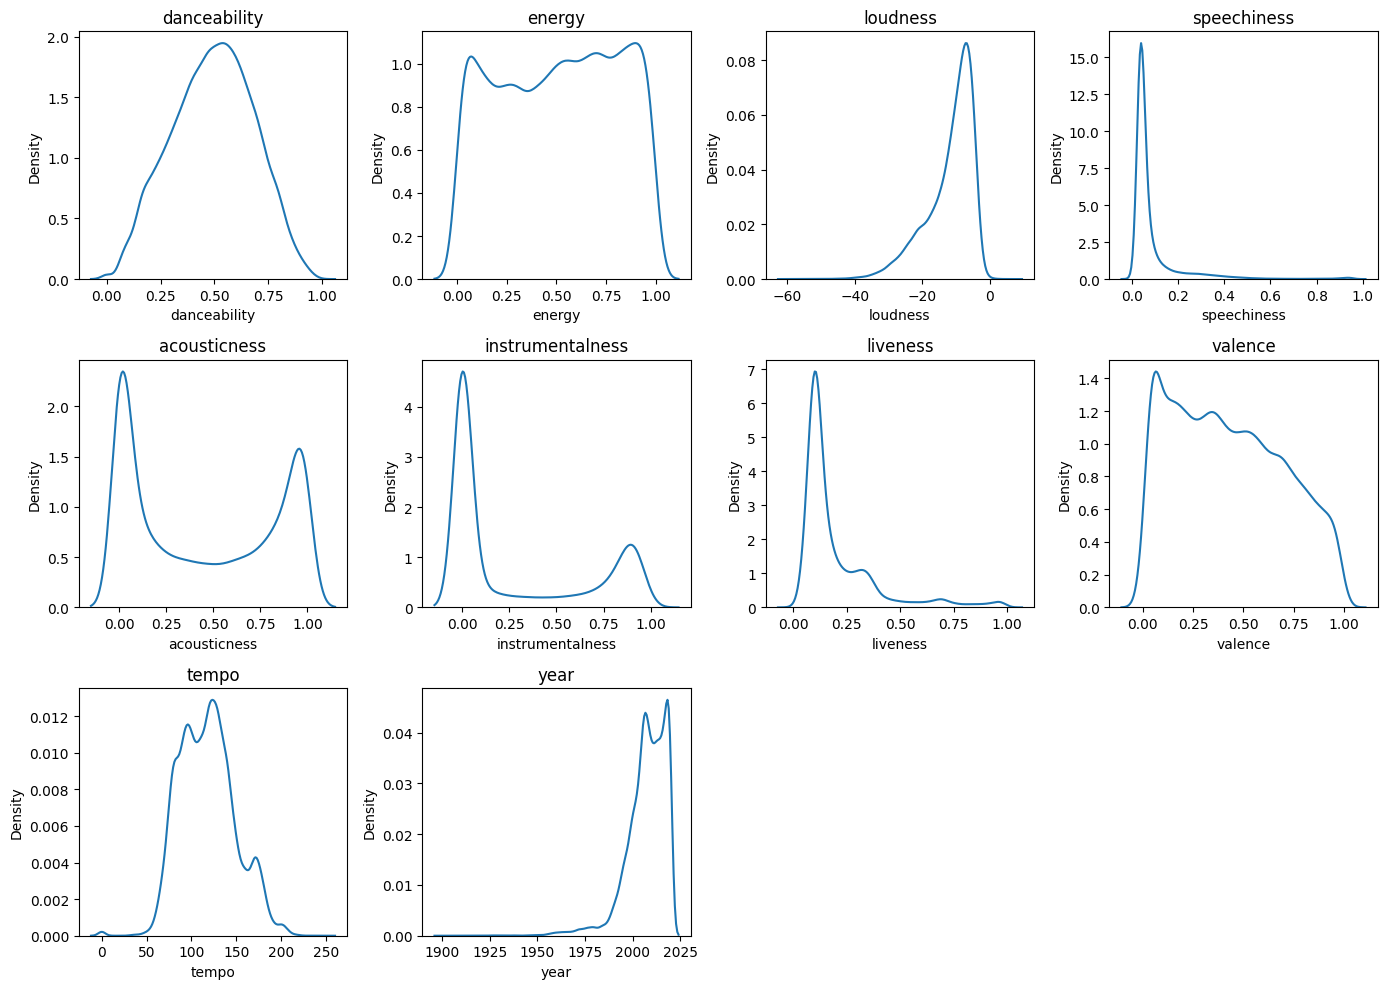

In [9]:
plt.figure(figsize=(14,10))

for i, col in enumerate(feature_cols):
    plt.subplot(3,4,i+1)
    sns.kdeplot(df_model[col], fill=False, bw_adjust=1.3)
    plt.title(col)

plt.tight_layout()
plt.show()

There are various distributions throughout the features. Acousticness and instrumentalness tend to be extremes. Tempo and danceability exhibit normal-distribution-type curves. Energy is consistent throughout the range, similar to a uniform distribution. The rest of the features tend to be skewed towards the left, with loudness and year being the exceptions in being skewed to the right. 

### Correlation Analysis

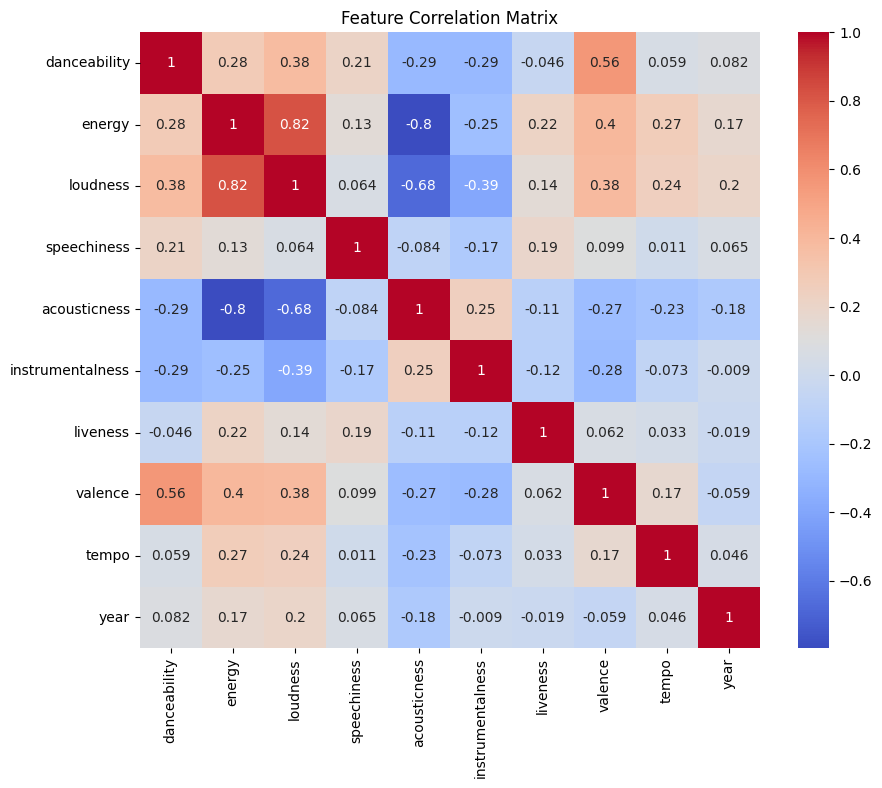

In [10]:
corr = df_model[feature_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

The correlation matrix most notably shows a positive correlation between loudness and energy, which is expected since louder tracks tend to have higher perceived energy. Furthermore, it depicts a negative correlation between energy, loudness and acousticness, which accentuates the difference of acoustic and electronic music styles.

### Feature Relationships

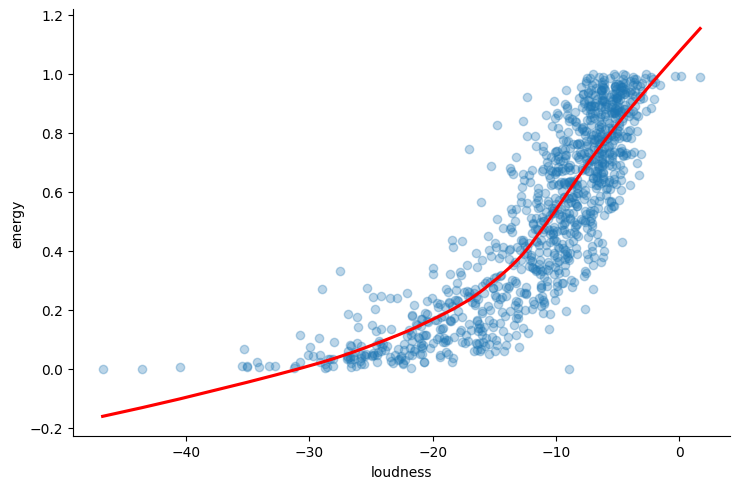

In [11]:
sns.lmplot(
    data=df_model.sample(1000),
    x="loudness",
    y="energy",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a positive association between loudness and energy of the songs. That is expected due to the nature of louder music being perceived as more energetic. 

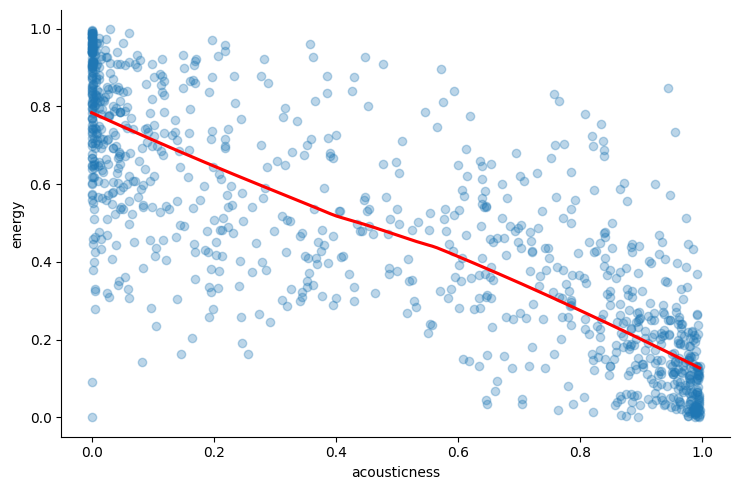

In [12]:
sns.lmplot(
    data=df_model.sample(1000),
    x="acousticness",
    y="energy",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a negative association between acousticness and energy of the songs. That is expected because electronic music (closer to 0 on the acousticness scale) tends to be more energetic than acoustic music.

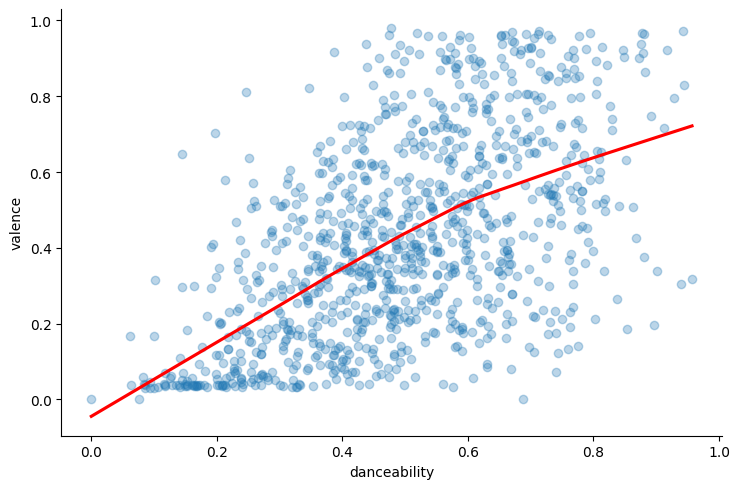

In [13]:
sns.lmplot(
    data=df_model.sample(1000),
    x="danceability",
    y="valence",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a positive association between danceability and valence of the songs. That is expected because the danceability benefits from the song being more positively connotated in an emotional way.

## Feature Scaling

Because the features have different scales (e.g. tempo vs danceability), the data is standardized and normalized before training the recommendation model.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype("float32")

X_normalized = normalize(X_scaled, norm="l2")

## Recommendation Model

A content-based recommender system is implemented using a Nearest Neighbors model with euclidean distance.

Songs are represented as vectors in a multi-dimensional feature space.  
The model identifies songs with the smallest euclidean distance to a given track.

In [15]:
nn_model = NearestNeighbors(
    n_neighbors=6,
    algorithm="brute",
    metric="euclidean"
)

nn_model.fit(X_normalized)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [16]:
df_model = df_model.reset_index(drop=True)

song_to_index = pd.Series(df_model.index, index=df_model["song_label"]).drop_duplicates()
song_to_index.head()

song_label
All Along The Watchtower - Live - 1991 - ['Indigo Girls']    0
90210 (feat. Kacy Hill) - ['Travis Scott', 'Kacy Hill']      1
Smokin' Sticky Sticky - ['Unk']                              2
Holding Back the Years - ['Norm Douglas']                    3
Windmills - ['Dan Friel']                                    4
dtype: int64

## Recommendation Function

In [17]:
def recommend_songs(song_label, n=5, year_range=None):

    if song_label not in song_to_index.index:
        return f"Song '{song_label}' not found."
    
    idx = song_to_index[song_label]
    
    song_vector = X_normalized[idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(song_vector, n_neighbors=50)

    recommended_indices = indices.flatten()[1:]
    recommended_distances = distances.flatten()[1:]

    result = df_model.loc[recommended_indices, ["song_label", "year"]].copy()
    result["euclidean_distance"] = recommended_distances

    if year_range is not None:
        min_year, max_year = year_range
        result = result[
            (result["year"] >= min_year) &
            (result["year"] <= max_year)
        ]

    return result.head(n)

## Song Search Function

In [18]:
def search_song(query, n=20):
    query = str(query).strip()
    
    matches = df_model[
        df_model["song_label"].str.contains(query, case=False, na=False)
    ][["name", "artists", "song_label", "year"]].head(n)
    
    if matches.empty:
        return f"No songs found for '{query}'."
    
    return matches

## Example Recommendations

In [19]:
search_song("All Along The Watchtower")

,name,artists,song_label,year
0,All Along The Watchtower - Live - 1991,['Indigo Girls'],All Along The Watchtower - Live - 1991 - ['Ind...,1991
7296,All Along the Watchtower,['Z-Star Delta'],All Along the Watchtower - ['Z-Star Delta'],2017
54809,All Along The Watchtower,['Taj Mahal'],All Along The Watchtower - ['Taj Mahal'],2003
92364,All Along the Watchtower - Live at Nippon Budo...,['Bob Dylan'],All Along the Watchtower - Live at Nippon Budo...,1979


In [20]:
recommend_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']")

,song_label,year,euclidean_distance
77846,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.175011
58767,"Minarets - Live at Luther College, Decorah, IA...",1999,0.200694
47654,"Turandot: Nessun dorma - ['Giacomo Puccini', '...",1988,0.242497
45420,Peggy Gordon - ['World Music'],1997,0.245297
13937,Rain - ['Little Charlie & The Nightcats'],1991,0.247796


In [21]:
recommend_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']", year_range=(1985, 1995))

,song_label,year,euclidean_distance
77846,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.175011
47654,"Turandot: Nessun dorma - ['Giacomo Puccini', '...",1988,0.242497
13937,Rain - ['Little Charlie & The Nightcats'],1991,0.247796
80197,Waltz for Leslie - ['Karl Denson'],1995,0.250952
65400,Now and Then - ['Susanna Hoffs'],1995,0.264220


In [22]:
search_song("90210")

,name,artists,song_label,year
1,90210 (feat. Kacy Hill),"['Travis Scott', 'Kacy Hill']","90210 (feat. Kacy Hill) - ['Travis Scott', 'Ka...",2015
27665,90210,['Giant Drag'],90210 - ['Giant Drag'],2013
94967,90210,['Smiley'],90210 - ['Smiley'],2020


In [23]:
recommend_songs("90210 (feat. Kacy Hill) - ['Travis Scott', 'Kacy Hill']")

,song_label,year,euclidean_distance
68232,Wicked Crush - ['Modern Kin'],2013,0.216862
82054,What They Say - ['Zara Larsson'],2017,0.248630
58353,(We Don't Have To) Walk Alone - ['BAYWUD'],2020,0.262433
97467,"Use Me (feat. 070 Shake) - ['PVRIS', '070 Shake']",2020,0.293045
93692,"Forward - ['Duumu', 'ÊMIA']",2018,0.293221


The recommended tracks exhibit similar values in energy, danceability and tempo, indicating that the model captures musical similarity in terms of audio features.

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_normalized)

df_model["PC1"] = X_pca[:,0]
df_model["PC2"] = X_pca[:,1]

In [25]:
pca = PCA(n_components=2)
pca.fit(X_normalized)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=feature_cols
)

print(loadings)

                       PC1       PC2
danceability      0.289863  0.532261
energy            0.502258 -0.281258
loudness          0.442823 -0.103757
speechiness       0.075819  0.003272
acousticness     -0.490349  0.346640
instrumentalness -0.266523 -0.375258
liveness          0.072962 -0.137679
valence           0.331606  0.506508
tempo             0.157501 -0.216736
year              0.101524 -0.208226


In [33]:
plt.style.use("seaborn-v0_8")
def pca_recommended_songs(song_label, year_ranged=None):
    rec = recommend_songs(song_label, year_range=year_ranged)

    rec_indices = rec.index

    plt.figure(figsize=(12,7))

    sample = df_model.sample(90000, random_state=42)

    # all songs
    sns.kdeplot(
        data=sample,
        x="PC1",
        y="PC2",
        fill=True,
        cmap="Blues",
        alpha=0.5,
        levels=10,
        thresh=0.05
    )

    sns.kdeplot(
        data=sample,
        x="PC1",
        y="PC2",
        color="black",
        levels=1,
        linewidths=0.5,
        thresh=0.05
    )

    # recommended songs
    plt.scatter(
        df_model.loc[rec_indices,"PC1"],
        df_model.loc[rec_indices,"PC2"],
        color="red",
        s=100,
        label="Recommendations"
    )

    plt.legend()
    plt.title("Recommended Songs in PCA Space")

    # input song
    song_idx = song_to_index[song_label]

    plt.scatter(
        df_model.loc[song_idx,"PC1"],
        df_model.loc[song_idx,"PC2"],
        color="black",
        s=150,
        label="Input Song"
    )

    plt.legend()
    # plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    return rec

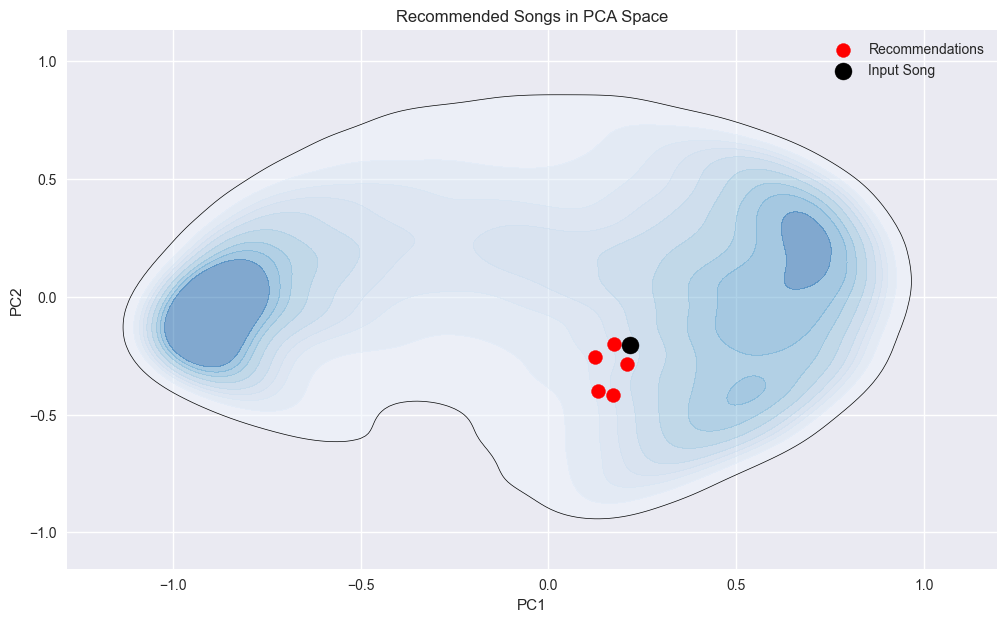

,song_label,year,euclidean_distance
68232,Wicked Crush - ['Modern Kin'],2013,0.216862
82054,What They Say - ['Zara Larsson'],2017,0.248630
58353,(We Don't Have To) Walk Alone - ['BAYWUD'],2020,0.262433
97467,"Use Me (feat. 070 Shake) - ['PVRIS', '070 Shake']",2020,0.293045
93692,"Forward - ['Duumu', 'ÊMIA']",2018,0.293221


In [34]:
pca_recommended_songs("90210 (feat. Kacy Hill) - ['Travis Scott', 'Kacy Hill']")

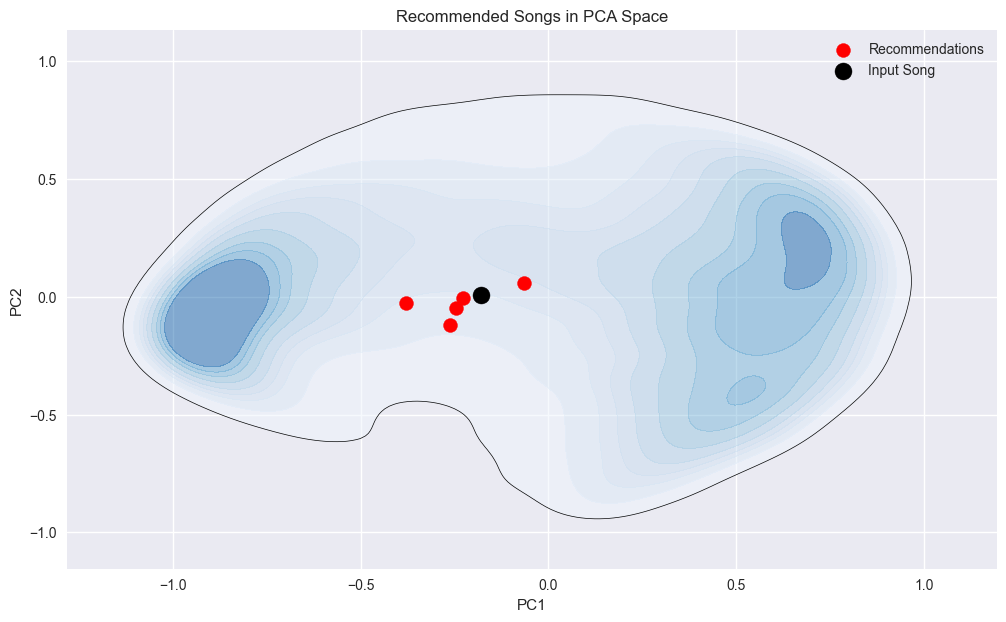

,song_label,year,euclidean_distance
77846,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.175011
47654,"Turandot: Nessun dorma - ['Giacomo Puccini', '...",1988,0.242497
13937,Rain - ['Little Charlie & The Nightcats'],1991,0.247796
80197,Waltz for Leslie - ['Karl Denson'],1995,0.250952
65400,Now and Then - ['Susanna Hoffs'],1995,0.264220


In [35]:
pca_recommended_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']", year_ranged=(1985, 1995))

## Clustering Analysis

To further investigate the structure of the dataset, K-means clustering was applied to the normalized audio features. \
The goal was to identify groups of songs with similar musical characteristics without relying on predefined genre labels.

In [37]:
kmeans = KMeans(n_clusters=8, random_state=42)

clusters = kmeans.fit_predict(X_normalized)

df_model["cluster"] = clusters

In [38]:
cluster_profile = df_model.groupby("cluster")[feature_cols].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
cluster,,,,,,,,,,
0,0.297734,0.150713,-21.766229,0.046800,0.868840,0.784160,0.139077,0.151306,101.654447,2005.858676
1,0.430056,0.775323,-6.325972,0.078019,0.091645,0.042355,0.179521,0.398938,138.678081,2010.588880
2,0.505258,0.636184,-9.883931,0.221515,0.371087,0.110891,0.614564,0.473618,116.821635,2008.174838
3,0.563311,0.467620,-11.826761,0.058373,0.498827,0.075953,0.171280,0.601130,120.746029,1987.806050
4,0.430568,0.225770,-15.208969,0.049412,0.809699,0.028230,0.144434,0.266807,108.899585,2008.237452
5,0.691415,0.669274,-7.508594,0.107842,0.229735,0.038509,0.152647,0.669772,113.779948,2011.228764
6,0.487972,0.745145,-8.439212,0.066797,0.081524,0.782532,0.176401,0.357512,126.682036,2010.811971
7,0.570759,0.374808,-14.689929,0.057620,0.766300,0.796538,0.141963,0.633683,123.101601,2007.236931


### Cluster Interpretation
Cluster analysis reveals meaningful groupings of songs based on their audio features.

- cluster 0: Low-energy acoustic tracks with low valence, representing calm or melancholic music. 
- cluster 1: High-energy electronic tracks with fast tempo, likely representing modern pop or electronic music. 
- cluster 2: Highly danceable and energetic tracks with positive valence, typical for mainstream pop or dance music. 
- cluster 3: Instrumental tracks with high energy and danceability, possibly electronic or cinematic music. 
- cluster 4: Moderately energetic acoustic tracks with positive valence, likely representing acoustic pop or indie music. 
- cluster 5: Electronic instrumental tracks with lower valence, possibly ambient or darker electronic music. 
- cluster 6: Very low-energy acoustic and instrumental tracks, likely ambient, classical, or background music. 
- cluster 7: Tracks with high liveness, indicating live recordings or concert-like audio characteristics. 

Overall, the clustering captures meaningful structure in the feature space without explicitly using genre labels.

In [39]:
cluster_names = {
    0: "Calm Acoustic",
    1: "Energetic Electronic",
    2: "Dance Pop",
    3: "Instrumental Energy",
    4: "Acoustic Pop",
    5: "Dark Electronic Instrumental",
    6: "Ambient / Classical",
    7: "Live Performances"
}

df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

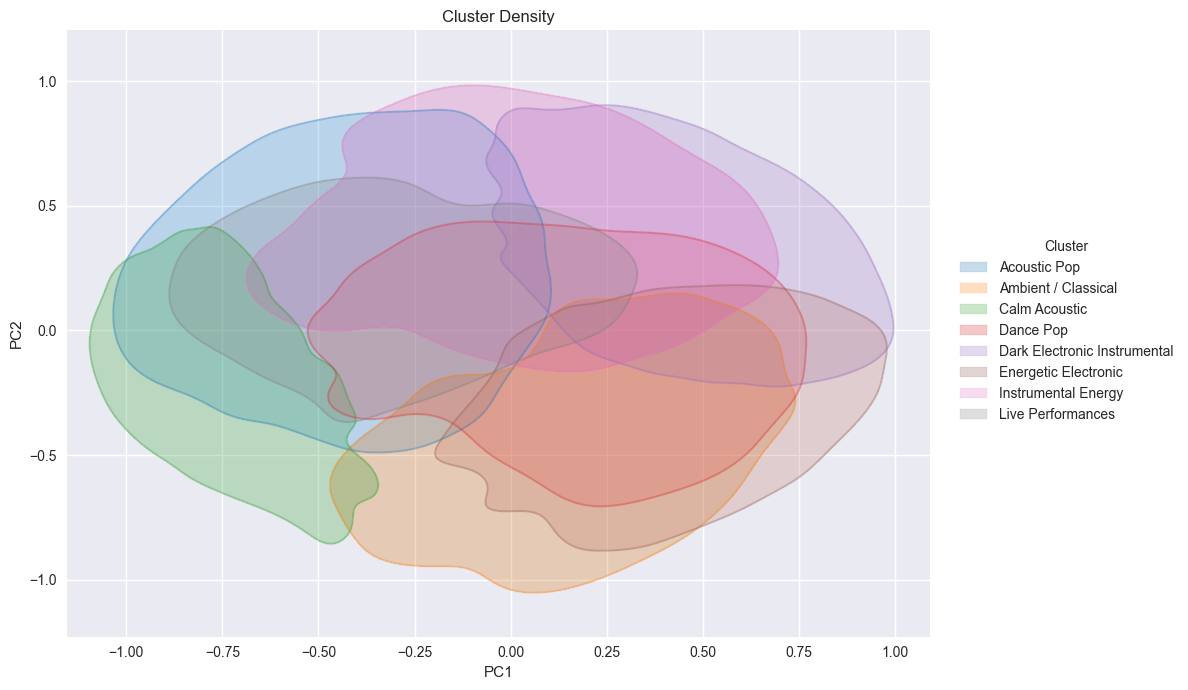

In [41]:
plt.figure(figsize=(12,7))

sample_df = df_model.sample(10000, random_state=42)

cluster_order = sorted(sample_df["cluster_name"].unique())

palette = dict(zip(cluster_order, sns.color_palette("tab10", n_colors=len(cluster_order))))

# Area
sns.kdeplot(
    data=sample_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_order,
    palette=palette,
    fill=True,
    alpha=0.25,
    levels=2,
    legend=False
)

# Contours
sns.kdeplot(
    data=sample_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_order,
    palette=palette,
    fill=False,
    alpha=0.3,
    levels=1,
    linewidths=1.5,
    legend=False
)

legend_handles = [
    Patch(facecolor=palette[name], edgecolor=palette[name], alpha=0.25, label=name)
    for name in cluster_order
]

plt.legend(
    handles=legend_handles,
    title="Cluster",
    bbox_to_anchor=(1.02, 0.675),
    loc="upper left"
)

plt.title("Cluster Density")
plt.tight_layout()
# plt.savefig("cluster_plot.png", dpi=300, bbox_inches="tight")
plt.show()

The PCA visualization reveals how songs are distributed in the feature space and how the clusters occupy distinct regions. 

While 8 clusters were used, some overlap between clusters was observed. \
Reducing the number of clusters lead to slightly more distinct groupings, but also reduced granularity. \
Therefore, 8 clusters were retained to capture more detailed structure in the data.

Overall, the chosen audio features are efficient in describing the songs because clusters can be defined and characterized by the features themselves.

## Limitations

This recommendation system is based solely on audio features and does not incorporate:

- user listening history
- collaborative filtering
- genre or artist similarity

Therefore, recommendations are purely based on musical characteristics rather than user preferences.

## Future Improvements

Possible extensions include:

- hybrid recommender systems
- incorporating genre information, building off of clustering 